In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded")


Matplotlib is building the font cache; this may take a moment.


Libraries loaded


In [2]:
df = pd.read_csv('../data/creditcard.csv')

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nFirst rows:")
df.head()


Rows: 284,807
Columns: 31

First rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Legitimate transactions: 284,315  (99.83%)
Fraudulent transactions: 492   (0.17%)


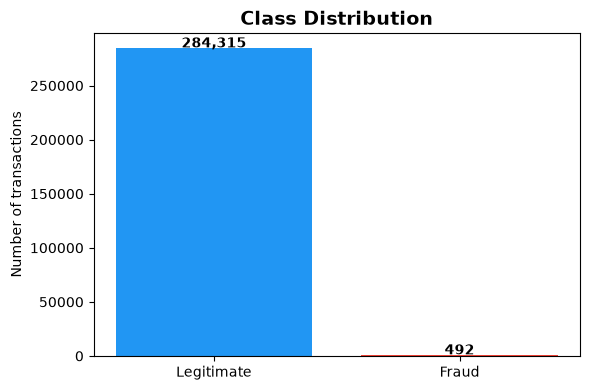

In [3]:
# Class distribution - the core challenge
fraud_counts = df['Class'].value_counts()

print(f"Legitimate transactions: {fraud_counts[0]:,}  ({fraud_counts[0]/len(df)*100:.2f}%)")
print(f"Fraudulent transactions: {fraud_counts[1]:,}   ({fraud_counts[1]/len(df)*100:.2f}%)")

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Legitimate', 'Fraud'], [fraud_counts[0], fraud_counts[1]],
       color=['#2196F3', '#F44336'])
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of transactions')

for i, v in enumerate([fraud_counts[0], fraud_counts[1]]):
    ax.text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=150)
plt.show()


In [4]:
# What are V1-V28?
print("""
Columns V1-V28 are the result of applying PCA (Principal Component Analysis).
The bank anonymized the real data for privacy reasons.

PCA transforms correlated variables into independent components.

The only NON-transformed columns are:
- Time:   seconds since the first transaction
- Amount: transaction amount in euros
- Class:  0 = legitimate, 1 = fraud  ← this is what we predict
""")

print("Transaction amount stats:")
print(df['Amount'].describe().round(2))



Columns V1-V28 are the result of applying PCA (Principal Component Analysis).
The bank anonymized the real data for privacy reasons.

PCA transforms correlated variables into independent components.

The only NON-transformed columns are:
- Time:   seconds since the first transaction
- Amount: transaction amount in euros
- Class:  0 = legitimate, 1 = fraud  ← this is what we predict

Transaction amount stats:
count    284807.00
mean         88.35
std         250.12
min           0.00
25%           5.60
50%          22.00
75%          77.16
max       25691.16
Name: Amount, dtype: float64


In [ ]:
# Data quality check
print("=== Data Quality ===")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Data types: {df.dtypes.value_counts().to_dict()}")

print("\n=== Fraud vs Legitimate: Average Amount ===")
print(df.groupby('Class')['Amount'].mean().round(2).rename({0: 'Legitimate', 1: 'Fraud'}))

print("\n=== Summary ===")
print(f"• Total transactions: {len(df):,}")
print(f"• Fraud rate: {df['Class'].mean()*100:.2f}%")
print(f"• Class imbalance ratio: 1 fraud per {int(fraud_counts[0]/fraud_counts[1])} legitimate")
print(f"• Missing values: {df.isnull().sum().sum()}")
print(f"\nChallenge: extreme class imbalance → solution: SMOTE + class weights")

=== Data Quality ===
